# Dự án Phát hiện Xe máy Chở 3 (Triple Rider Detection) bằng YOLOv8
Notebook này chứa toàn bộ mã nguồn tích hợp bộ dữ liệu Roboflow từ dự án mẫu và cấu hình quy trình huấn luyện YOLOv8 chuẩn trên Google Colab.

## Bước 1: Cài đặt Thư viện và Kiểm tra Môi trường
Chúng ta cần cài đặt thư viện `ultralytics` cho YOLOv8 và `roboflow` để tải trực tiếp bộ dữ liệu từ kho lưu trữ.

In [ ]:
# Kiểm tra GPU được cấp phát
!nvidia-smi

# Cài đặt các thư viện cần thiết
!pip install ultralytics roboflow

# Kiểm tra cấu hình cài đặt YOLOv8
import ultralytics
ultralytics.checks()

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.5/107.7 GB disk)


## Bước 2: Kết nối Google Drive
Kết nối Drive giúp bạn tự động lưu lại các file trọng số (.pt) tốt nhất sau khi huấn luyện xong.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Bước 3: Tải Dataset trực tiếp từ Roboflow Universe
Đoạn mã này sử dụng API Key từ dự án gốc để tự động tải hơn 6,000 ảnh cùng nhãn dán định dạng YOLOv8 về máy ảo Colab.

In [ ]:
from roboflow import Roboflow
import os

# Khởi tạo API tải dataset từ Workspace 'kashish' - Dự án '3riders'
rf = Roboflow(api_key="3OEqKlaUTLNgrFZGJiv6")
project = rf.workspace("kashish").project("3riders")
version = project.version(2)

# Tải bộ dữ liệu theo cấu trúc YOLOv8
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to 3riders-2 in yolov8:: 100%|██████████| 12126/12126 [00:01<00:00, 6746.69it/s]


## Bước 4: Kiểm tra và Đọc nội dung file Cấu hình `data.yaml`
Roboflow sẽ tự tạo file `data.yaml`. Chúng ta kiểm tra để đảm bảo đường dẫn và các lớp nhãn (rider, bike, helmet, without helmet, phone) đã đúng chuẩn.

In [ ]:
# Đường dẫn mặc định của file yaml sau khi tải từ Roboflow
yaml_path = os.path.join(dataset.location, 'data.yaml')

print(f"Đường dẫn file yaml: {yaml_path}")
print("--- Nội dung cấu hình file ---")
with open(yaml_path, 'r') as f:
    print(f.read())

Đường dẫn file yaml: /content/3riders-2/data.yaml
--- Nội dung cấu hình file ---
names:
- MORE_THAN_TWO_PERSONS
- USING_MOBILE
- WITHOUT_HELMET
- WITH_HELMET
- normal
nc: 5
roboflow:
  license: CC BY 4.0
  project: 3riders
  url: https://universe.roboflow.com/kashish/3riders/dataset/2
  version: 2
  workspace: kashish
test: ../test/images
train: ../train/images
val: ../valid/images



## Bước 5: Tiến hành Huấn luyện Mô hình với YOLOv8
Chúng ta sẽ sử dụng phiên bản `yolov8n.pt` (Nano) để tối ưu tốc độ. Kết quả sẽ được xuất thẳng vào thư mục làm việc trên Google Drive của bạn.

In [ ]:
from ultralytics import YOLO

# Khởi tạo mô hình pre-trained
model = YOLO('yolov8s.pt')

# Thực hiện quá trình huấn luyện
results = model.train(
    data=os.path.join(dataset.location, 'data.yaml'), # Đường dẫn file yaml từ Roboflow
    epochs=50,                                        # Số lượng epoch huấn luyện
    imgsz=640,                                        # Kích thước ảnh
    batch=16,                                         # Batch size (hạ xuống 8 nếu bị tràn bộ nhớ VRAM)
    device=0,                                         # Sử dụng GPU
    workers=2,                                        # Số luồng CPU tải dữ liệu
    project='/content/drive/MyDrive/YOLOv8_3Riders',  # Lưu trực tiếp vào Google Drive để tránh mất mát
    name='triple_rider_run_1',                        # Tên phiên chạy
    exist_ok=True
)

Ultralytics 8.4.69 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/3riders-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=triple_rider_run_1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

## Bước 6: Đánh giá Chất lượng và Kiểm thử Thử nghiệm (Inference)
Kiểm tra lại các chỉ số độ chính xác mAP và chạy thử dự đoán trên một ảnh mẫu ngẫu nhiên từ mạng internet.

In [ ]:
# Đánh giá mô hình trên tập Validation
metrics = model.val()
print(f"mAP50-95 đạt: {metrics.box.map:.4f}")
print(f"mAP50 đạt: {metrics.box.map50:.4f}")

# Chạy thử nghiệm nhận diện dự đoán
test_url = 'https://ultralytics.com/images/bus.jpg'
model.predict(
    source=test_url,
    conf=0.25,
    save=True,
    project='/content/drive/MyDrive/YOLOv8_3Riders',
    name='predict_test'
)

Ultralytics 8.4.69 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1385.8±550.6 MB/s, size: 39.6 KB)
val: Scanning /content/3riders-2/valid/labels.cache... 514 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 514/514 143.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 33/33 3.3it/s 10.1s
                   all        514        952      0.827      0.743      0.808      0.456
 MORE_THAN_TWO_PERSONS        251        254      0.865      0.882      0.924      0.585
          USING_MOBILE        153        159      0.843      0.742      0.848      0.447
        WITHOUT_HELMET        115        298      0.767      0.663      0.727      0.372
           WITH_HELMET        152        230      0.884      0.792      0.882      0.521
                normal         10         1

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'MORE_THAN_TWO_PERSONS', 1: 'USING_MOBILE', 2: 'WITHOUT_HELMET', 3: 'WITH_HELMET', 4: 'normal'}
 obb: None
 orig_img: array([[[119, 146, 172],
         [121, 148, 174],
         [122, 152, 177],
         ...,
         [161, 171, 188],
         [160, 170, 187],
         [160, 170, 187]],
 
        [[120, 147, 173],
         [122, 149, 175],
         [123, 153, 178],
         ...,
         [161, 171, 188],
         [160, 170, 187],
         [160, 170, 187]],
 
        [[123, 150, 176],
         [124, 151, 177],
         [125, 155, 180],
         ...,
         [161, 171, 188],
         [160, 170, 187],
         [160, 170, 187]],
 
        ...,
 
        [[183, 182, 186],
         [179, 178, 182],
         [180, 179, 183],
         ...,
         [121, 111, 117],
         [113, 103, 109],
         [115, 105, 111]],
 
        [[165, 164, 168]

In [ ]:
from google.colab import files

# Đường dẫn tới file trọng số tốt nhất (best.pt) nằm trong Google Drive của bạn
best_model_path = '/content/drive/MyDrive/YOLOv8_3Riders/triple_rider_run_1/weights/best.pt'

# Lệnh kích hoạt tải file về máy tính cá nhân
if os.path.exists(best_model_path):
    files.download(best_model_path)
    print("Đang tải file best.pt về máy tính của bạn...")
else:
    print("Không tìm thấy file! Bạn hãy kiểm tra xem quá trình huấn luyện đã chạy xong chưa nhé.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Đang tải file best.pt về máy tính của bạn...


--- Đang kết nối với Google Drive... ---
Mounted at /content/drive
--- Khởi tạo thuật toán định danh đa lỗi thành công! ---

📊 [BÁO CÁO KẾT QUẢ ĐỊNH DANH PHẠT NGUỘI TỔNG HỢP]:

🏍️ Kiểm tra Xe máy số #1:
  ❌ TRẠNG THÁI: PHÁT HIỆN TỔNG CỘNG 1 LỖI VI PHẠM TRÊN XE NÀY!
    1. Lỗi: USING_MOBILE (52.0%)
  👉 Đã xuất ảnh bằng chứng chứa TOÀN BỘ lỗi của xe #1 tại: /content/xe_vi_pham_so_1.jpg

🏍️ Kiểm tra Xe máy số #2:
  ❌ TRẠNG THÁI: PHÁT HIỆN TỔNG CỘNG 2 LỖI VI PHẠM TRÊN XE NÀY!
    1. Lỗi: WITHOUT_HELMET (79.0%)
    2. Lỗi: WITHOUT_HELMET (77.0%)
  👉 Đã xuất ảnh bằng chứng chứa TOÀN BỘ lỗi của xe #2 tại: /content/xe_vi_pham_so_2.jpg

🏍️ Kiểm tra Xe máy số #3:
  🎉 TRẠNG THÁI: Chấp hành đúng luật, không phát hiện vi phạm.


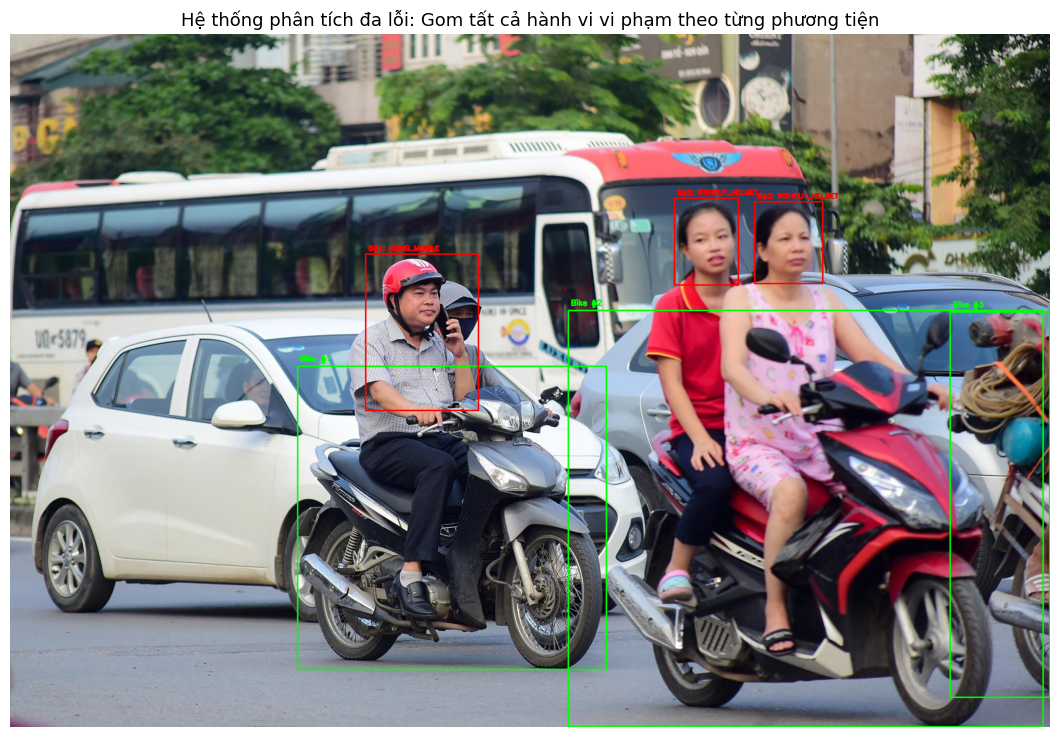

In [ ]:
import os
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from ultralytics import YOLO

# =====================================================================
# BƯỚC 1: KẾT NỐI DRIVE & KHỞI TẠO 2 MODEL
# =====================================================================
print("--- Đang kết nối với Google Drive... ---")
drive.mount('/content/drive', force_remount=True)

# 1. Model tùy chỉnh của bạn (Tìm lỗi hành vi)
VIOLATION_MODEL_PATH = '/content/drive/MyDrive/YOLOv8_3Riders/triple_rider_run_1/weights/best.pt'
if not os.path.exists(VIOLATION_MODEL_PATH):
    raise FileNotFoundError(f"Không tìm thấy file model tùy chỉnh tại: {VIOLATION_MODEL_PATH}")
violation_model = YOLO(VIOLATION_MODEL_PATH)

# 2. Model COCO (Định vị xe máy)
vehicle_model = YOLO("yolov8n.pt")
print("--- Khởi tạo thuật toán định danh đa lỗi thành công! ---")

# Cấu hình ngưỡng lọc
CONF_TRIPLE_RIDER = 0.50
CONF_OTHER_VIOLATIONS = 0.25
CONF_VEHICLE_LIMIT = 0.40

IMAGE_PATH = '/content/test4.jpg'

# =====================================================================
# CÁC HÀM TRỢ GIÚP TÍNH TOÁN HẬU XỬ LÝ (POST-PROCESSING)
# =====================================================================
def get_bottom_center(box):
    """Tính tâm đáy (x_center, y_max) - điểm tiếp xúc mặt đường của Box"""
    x1, y1, x2, y2 = box
    return ((x1 + x2) / 2, y2)

def calculate_distance(p1, p2):
    """Tính khoảng cách hình học Euclid giữa 2 điểm"""
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

# =====================================================================
# BƯỚC 2: XỬ LÝ CHÍNH - QUÉT VÀ LIÊN KẾT ĐA LỖI VÀO TỪNG XE INDEPENDENT
# =====================================================================
if not os.path.exists(IMAGE_PATH):
    print(f"⚠️ Vui lòng upload ảnh cần kiểm tra vào Colab và đặt tên là '{IMAGE_PATH}'")
else:
    img = cv2.imread(IMAGE_PATH)
    img_h, img_w, _ = img.shape
    img_display = img.copy()

    # 1. Định vị tất cả xe máy có trong ảnh
    vehicle_results = vehicle_model(IMAGE_PATH, conf=CONF_VEHICLE_LIMIT, verbose=False)[0]
    detected_bikes = []
    bike_counter = 0

    for v_box in vehicle_results.boxes:
        v_cls_id = int(v_box.cls[0].item())
        if v_cls_id == 3:  # Xe máy
            bike_counter += 1
            bx1, by1, bx2, by2 = map(int, v_box.xyxy[0].tolist())
            detected_bikes.append({
                "bike_id": bike_counter,
                "box": [bx1, by1, bx2, by2],
                "bottom_center": get_bottom_center([bx1, by1, bx2, by2]),
                "violations": []  # Danh sách gom tất cả các lỗi của xe này
            })

            # Vẽ khung xe máy (Màu xanh lá) - Tối ưu chống đè chữ biên trên
            cv2.rectangle(img_display, (bx1, by1), (bx2, by2), (0, 255, 0), 2)
            bike_text_y = by1 - 10 if by1 - 10 > 20 else by1 + 20
            cv2.putText(img_display, f"Bike #{bike_counter}", (bx1 + 5, bike_text_y),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # 2. Quét tất cả các lỗi hành vi xuất hiện trên toàn ảnh
    violation_results = violation_model(IMAGE_PATH, conf=0.20, verbose=False)[0]

    for vio_box in violation_results.boxes:
        cls_id = int(vio_box.cls[0].item())
        conf = float(vio_box.conf[0].item())
        class_name = violation_model.names[cls_id]

        # Lọc theo phân cấp ngưỡng cứng của bạn
        is_valid = False
        if cls_id == 0 and conf >= CONF_TRIPLE_RIDER:       # MORE_THAN_TWO_PERSONS
            is_valid = True
        elif cls_id in [1, 2] and conf >= CONF_OTHER_VIOLATIONS: # USING_MOBILE, WITHOUT_HELMET
            is_valid = True

        if is_valid:
            x1, y1, x2, y2 = map(int, vio_box.xyxy[0].tolist())
            vio_bottom_center = get_bottom_center([x1, y1, x2, y2])

            # Liên kết lỗi vào chiếc xe máy có khoảng cách tâm đáy gần nhất
            if len(detected_bikes) > 0:
                distances = [calculate_distance(vio_bottom_center, bike["bottom_center"]) for bike in detected_bikes]
                closest_bike_idx = np.argmin(distances)
                target_bike = detected_bikes[closest_bike_idx]

                # Thêm lỗi này vào danh sách violations của chiếc xe máy đó
                target_bike["violations"].append({
                    "class_name": class_name,
                    "confidence": round(conf, 2),
                    "box": [x1, y1, x2, y2]
                })

                # Vẽ hộp lỗi (Màu đỏ) lên ảnh tổng thể - Tối ưu vị trí chữ nhãn
                cv2.rectangle(img_display, (x1, y1), (x2, y2), (0, 0, 255), 2)
                violate_text_y = y1 - 7 if y1 - 7 > 15 else y1 + 18
                cv2.putText(img_display, f"B#{target_bike['bike_id']}: {class_name}",
                            (x1 + 5, violate_text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 255), 2)
            else:
                print(f"⚠️ Phát hiện lỗi {class_name} nhưng không có xe máy nào ở gần để gán.")

    # =====================================================================
    # BƯỚC 3: XUẤT BÁO CÁO TỔNG HỢP ĐA LỖI & CẮT ẢNH BẰNG CHỨNG TỐI ƯU
    # =====================================================================
    print("\n📊 [BÁO CÁO KẾT QUẢ ĐỊNH DANH PHẠT NGUỘI TỔNG HỢP]:")

    for bike in detected_bikes:
        print(f"\n🏍️ Kiểm tra Xe máy số #{bike['bike_id']}:")

        if len(bike["violations"]) > 0:
            print(f"  ❌ TRẠNG THÁI: PHÁT HIỆN TỔNG CỘNG {len(bike['violations'])} LỖI VI PHẠM TRÊN XE NÀY!")

            # Khởi tạo tọa độ cắt ảnh ban đầu bằng chính box của chiếc xe máy
            cx1, cy1, cx2, cy2 = bike["box"]

            for idx, v in enumerate(bike["violations"]):
                print(f"    {idx+1}. Lỗi: {v['class_name']} ({v['confidence']*100}%)")

                # THUẬT TOÁN PHÌNH BOX ĐỘNG: So sánh mở rộng tọa độ để ôm trọn tất cả các hộp lỗi gán cho xe
                vx1, vy1, vx2, vy2 = v["box"]
                cx1 = min(cx1, vx1)
                cy1 = min(cy1, vy1)
                cx2 = max(cx2, vx2)
                cy2 = max(cy2, vy2)

            # Thêm biên an toàn (Padding) 8% xung quanh để ảnh cắt đẹp, không sát rìa box lỗi
            pad_w = int((cx2 - cx1) * 0.08)
            pad_h = int((cy2 - cy1) * 0.08)

            final_crop_x1 = max(0, cx1 - pad_w)
            final_crop_y1 = max(0, cy1 - pad_h)
            final_crop_x2 = min(img_w, cx2 + pad_w)
            final_crop_y2 = min(img_h, cy2 + pad_h)

            # Thực hiện cắt ảnh bằng chứng tích hợp toàn bộ các lỗi
            crop_target = img[final_crop_y1:final_crop_y2, final_crop_x1:final_crop_x2]
            if crop_target.size > 0:
                file_name = f"/content/xe_vi_pham_so_{bike['bike_id']}.jpg"
                cv2.imwrite(file_name, crop_target)
                print(f"  👉 Đã xuất ảnh bằng chứng chứa TOÀN BỘ lỗi của xe #{bike['bike_id']} tại: {file_name}")
        else:
            print("  🎉 TRẠNG THÁI: Chấp hành đúng luật, không phát hiện vi phạm.")

    # Hiển thị kết quả đồ họa trực quan
    img_rgb = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(14, 9))
    plt.imshow(img_rgb)
    plt.title("Hệ thống phân tích đa lỗi: Gom tất cả hành vi vi phạm theo từng phương tiện", fontsize=13)
    plt.axis('off')
    plt.show()